In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
import pandas as pd

trades = pd.read_csv(r"C:\Users\Admin\Downloads\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\Admin\Downloads\fear_greed_index.csv")

print("Loaded successfully")

Loaded successfully


In [13]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [14]:
# Convert to datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Extract date only
trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

print("Cleaned")

Cleaned


In [15]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.head())

Empty DataFrame
Columns: [Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp, date, timestamp, value, classification]
Index: []


In [32]:
performance = merged.groupby('classification')['Closed PnL'].agg(['mean','sum','count'])
print(performance)

                      mean           sum  count
classification                                 
Extreme Fear     26.578119  4.867782e+05  18315
Extreme Greed   120.893258  1.356422e+06  11220
Fear             86.681258  2.460968e+06  28391
Greed            78.677868  1.030916e+06  13103
Neutral          41.957142  3.438807e+05   8196


In [16]:
performance = merged.groupby('classification')['Closed PnL'].mean()

print(performance)

Series([], Name: Closed PnL, dtype: float64)


In [19]:
print(trades['date'].head())
print(sentiment['date'].head())

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: date, dtype: object
0    2018-01-02
1    2018-02-02
2    2018-03-02
3    2018-04-02
4    2018-05-02
Name: date, dtype: object


In [30]:
print(trades['Timestamp'].head())

83771   1970-01-01 00:28:00
83770   1970-01-01 00:28:00
83769   1970-01-01 00:28:00
39280   1970-01-01 00:28:20
39641   1970-01-01 00:28:20
Name: Timestamp, dtype: datetime64[ns]


Merged shape: (79225, 20)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID 

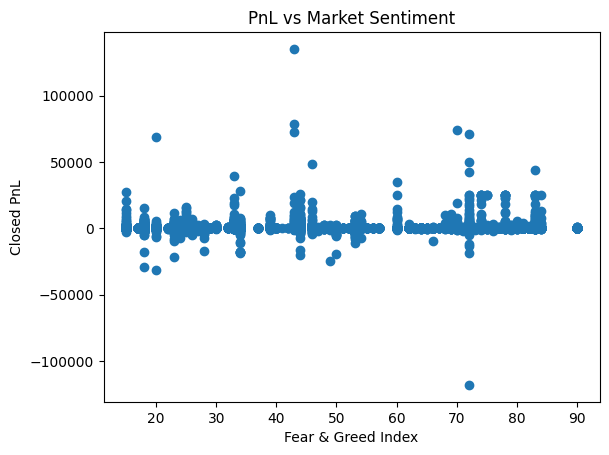

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
trades = pd.read_csv(r"C:\Users\Admin\Downloads\historical_data.csv")
sentiment = pd.read_csv(r"C:\Users\Admin\Downloads\fear_greed_index.csv")

# -------------------------------
# STEP 1: Use correct timestamp column
# -------------------------------
trades['Timestamp'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# -------------------------------
# STEP 2: Drop nulls (important)
# -------------------------------
trades = trades.dropna(subset=['Timestamp'])
sentiment = sentiment.dropna(subset=['date'])

# -------------------------------
# STEP 3: Extract only date
# -------------------------------
trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# -------------------------------
# STEP 4: Merge datasets
# -------------------------------
merged = pd.merge(trades, sentiment, on='date', how='inner')

print("Merged shape:", merged.shape)
print(merged.head())

# -------------------------------
# STEP 5: Basic analysis
# -------------------------------
performance = merged.groupby('classification')['Closed PnL'].mean()

print("\nPerformance by Sentiment:")
print(performance)

# -------------------------------
# STEP 6: Visualization
# -------------------------------
plt.figure()
plt.scatter(merged['value'], merged['Closed PnL'])
plt.xlabel("Fear & Greed Index")
plt.ylabel("Closed PnL")
plt.title("PnL vs Market Sentiment")
plt.show()

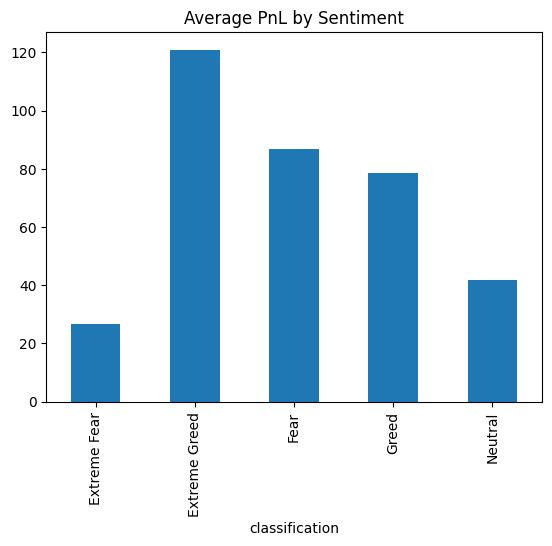

In [33]:
performance['mean'].plot(kind='bar', title="Average PnL by Sentiment")
plt.show()

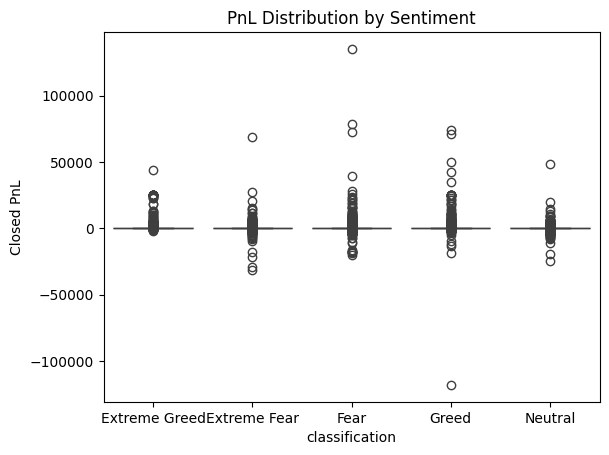

In [35]:
import seaborn as sns

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution by Sentiment")
plt.show()

In [36]:
correlation = merged['value'].corr(merged['Closed PnL'])
print("Correlation:", correlation)

Correlation: 0.02038483401955751


In [40]:
coin_perf = merged.groupby('Coin')['Closed PnL'].mean().sort_values(ascending=False)
print(coin_perf.head())

Coin
SEI       760.335893
USUAL     425.620183
ENA       411.161635
DOGE      391.346186
PEOPLE    360.646005
Name: Closed PnL, dtype: float64


In [38]:
side_perf = merged.groupby('Side')['Closed PnL'].mean()
print(side_perf)

Side
BUY     65.567673
SELL    77.367954
Name: Closed PnL, dtype: float64


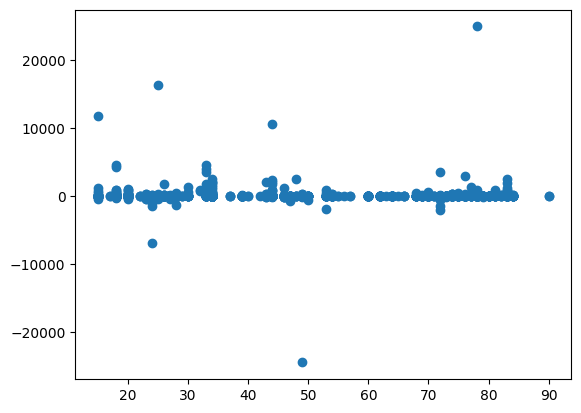

In [39]:
merged_sample = merged.sample(2000)
plt.scatter(merged_sample['value'], merged_sample['Closed PnL'])